Part I - a: Points in High Dimensional Space:


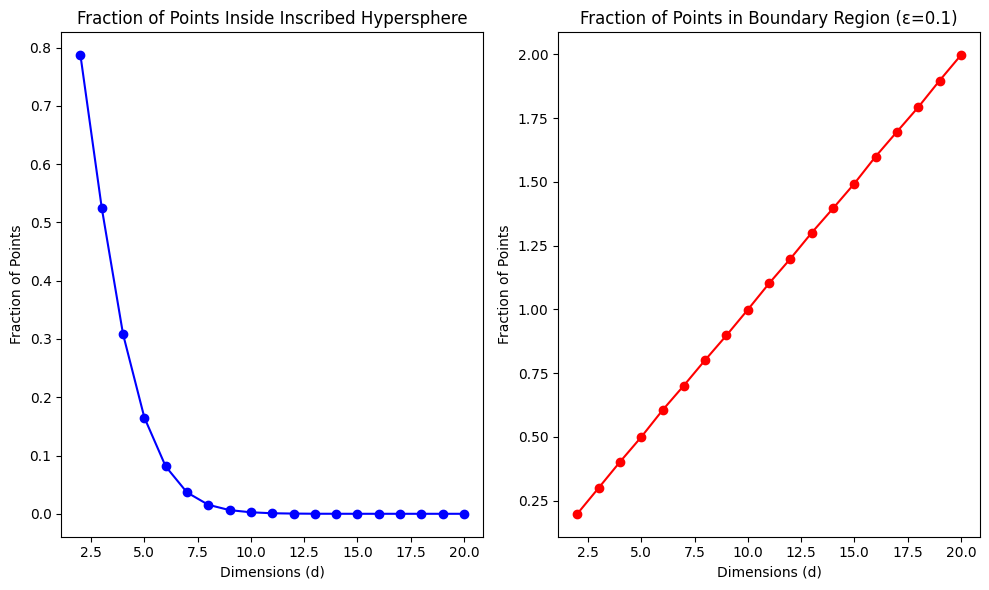

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Parameters
np.random.seed(42) #Random seed set for replicable results
n = 100000 #100,000 points
dimensions = np.arange(2, 21, 1) #dimensions, or D, varies from 2 to 20
hypercube_length = 2 
epsilon = 0.1 #the ε-width along hypercube boundary
points_hypersphere = []
points_boundary_region = []
hypersphere_radius = hypercube_length / 2

#For each dimension:
for i in dimensions:
    points = np.random.uniform(-1, 1, (n, i)) #n random points in d-dimension hypercube
    euclidean_dist = np.linalg.norm(points, axis=1) #euclidean distance from origin
    
    #Find fraction of points inside inscribed hypersphere
    fraction_hypersphere = np.sum(euclidean_dist <= hypersphere_radius) / n
    points_hypersphere.append(fraction_hypersphere)
    
    #Find fraction of points in the ε-width boundary region
    fraction_boundary = np.sum(np.abs(points) >= 1 - epsilon) / n
    points_boundary_region.append(fraction_boundary)

#Plotting
print("Part I - a: Points in High Dimensional Space:")
plt.figure(figsize=(10, 6)) #Prevents text from being covered in plots

#Plot points in hypersphere
plt.subplot(1, 2, 1) #Params: # of rows, # of cols, index#
plt.plot(dimensions, points_hypersphere, marker='o', color='blue')
plt.title('Fraction of Points Inside Inscribed Hypersphere')
plt.xlabel('Dimensions (d)')
plt.ylabel('Fraction of Points')

#Plot points in boundary
plt.subplot(1, 2, 2)
plt.plot(dimensions, points_boundary_region, marker='o', color='red')
plt.title('Fraction of Points in Boundary Region (ε=0.1)')
plt.xlabel('Dimensions (d)')
plt.ylabel('Fraction of Points')

plt.tight_layout()
plt.show()


Part I - b: High Dimensional Normal Distribution:
[0.6943538324955699, 0.6981863902933712, 0.7063870141962559, 0.7093194949756381]
Dimension 10: Mean Distance = 3.0940, Std Deviation = 0.6944
Dimension 50: Mean Distance = 7.0374, Std Deviation = 0.6982
Dimension 100: Mean Distance = 9.9749, Std Deviation = 0.7064
Dimension 500: Mean Distance = 22.3560, Std Deviation = 0.7093


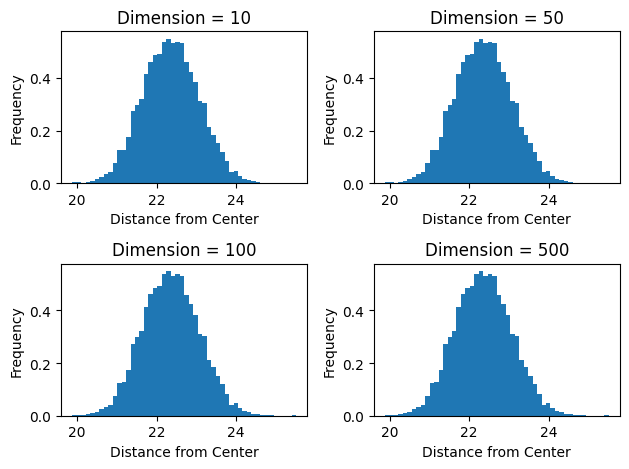

In [3]:
print("Part I - b: High Dimensional Normal Distribution:")

#Parameters:
n = 10000 #number of points
dimensions = [10, 50, 100, 500]
mean_distance_list = []
std_deviation_list = []

#For each dimension:
for d in dimensions:
    mean = np.zeros(d)
    covariance_matrix = np.identity(d)
    points = np.random.multivariate_normal(mean, covariance_matrix, n) #n data points from multivariate normal distribution in d dimensions
    euclidean_dist = np.linalg.norm(points, axis=1) #euclidean distance from origin

    #Find mean distance
    mean_distance = np.mean(euclidean_dist)
    mean_distance_list.append(mean_distance)

    #Find standard deviation
    std_deviation = np.std(euclidean_dist)
    std_deviation_list.append(std_deviation)

#Printing calculated mean distances and standard deviations
print(std_deviation_list)
for i, d in enumerate(dimensions):
    print(f"Dimension {d}: Mean Distance = {mean_distance_list[i]:.4f}, Std Deviation = {std_deviation_list[i]:.4f}")

#Plotting histograms of distances for each dimension
for i, d in enumerate(dimensions):
    plt.subplot(2, 2, i+1)
    plt.hist(euclidean_dist, bins=50, density=True)
    plt.title(f'Dimension = {d}')
    plt.xlabel('Distance from Center')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [12]:
#Loading in our wine dataset
wine_data = pd.read_csv('winequality-red.csv', delimiter=';')
x = wine_data.iloc[:, :-1].values  # First 11 attributes as independent variables
y = wine_data.iloc[:, -1].values   # Last attribute (quality) as the target variable

#Augmenting x by adding a column of ones as the first dimension
x_augmented = np.column_stack((np.ones(x.shape[0]), x))

#Performing QR factorization on x_augmented
n, m = x_augmented.shape
Q = np.zeros((n, m))
R = np.zeros((m, m))
for j in range(m):
    v = x_augmented[:, j]
    for i in range(j):
        R[i, j] = np.dot(Q[:, i], x_augmented[:, j])
        v = v - (R[i, j] * Q[:, i])
    R[j, j] = np.linalg.norm(v)
    Q[:, j] = v / np.linalg.norm(v)
print(x)
#Finding the weight vector using numpy.linalg.inv and printing it
w = np.linalg.inv(R).dot(Q.T).dot(y)
print("Weight Vector (w):")
print(w)

#Computing SSE (Sum of Squared Errors), TSS (Total Sum of Squares), and R^2
#Printing SEE and R_square as well.
y_hat = np.dot(x_augmented, w)
SSE = np.sum((y - y_hat)**2)
TSS = np.sum((y - np.mean(y))**2)
R_squared = (TSS-SSE)/TSS
print("SSE (Sum of Squared Errors):", SSE)
print("R^2 (R-squared):", R_squared)


[[ 1.     7.4    0.7   ...  3.51   0.56   9.4  ]
 [ 1.     7.8    0.88  ...  3.2    0.68   9.8  ]
 [ 1.     7.8    0.76  ...  3.26   0.65   9.8  ]
 ...
 [ 1.     6.3    0.51  ...  3.42   0.75  11.   ]
 [ 1.     5.9    0.645 ...  3.57   0.71  10.2  ]
 [ 1.     6.     0.31  ...  3.39   0.66  11.   ]]
Weight Vector (w):
[ 2.19652084e+01  2.49905527e-02 -1.08359026e+00 -1.82563948e-01
  1.63312698e-02 -1.87422516e+00  4.36133331e-03 -3.26457970e-03
 -1.78811638e+01 -4.13653144e-01  9.16334413e-01  2.76197699e-01]
[[ 1.     7.4    0.7   ...  3.51   0.56   9.4  ]
 [ 1.     7.8    0.88  ...  3.2    0.68   9.8  ]
 [ 1.     7.8    0.76  ...  3.26   0.65   9.8  ]
 ...
 [ 1.     6.3    0.51  ...  3.42   0.75  11.   ]
 [ 1.     5.9    0.645 ...  3.57   0.71  10.2  ]
 [ 1.     6.     0.31  ...  3.39   0.66  11.   ]]
SSE (Sum of Squared Errors): 666.4107003870316
R^2 (R-squared): 0.360551703038688
